# Device Check

In [1]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
# ============================================================
# Install Required Packages
# ============================================================

!pip install -q \
transformers==4.57.1 \
trl==0.21.0 \
peft==0.18.0 \
accelerate \
datasets \
qwen-vl-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 81.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 49.4 MB/s eta 0:00:00:00:0100:01


In [3]:
# ============================================================
# Project Information
# ============================================================
# Project : Vehicle Vision Assistant
# Model   : Qwen/Qwen3-VL-8B-Instruct
# Dataset : Paulescu/stanford_cars
# Method  : LoRA Fine-Tuning
# Platform: Kaggle (CUDA)
# ============================================================

import platform
import torch
import transformers

print("=" * 60)
print("Environment Information")
print("=" * 60)

print(f"Python Version      : {platform.python_version()}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Transformers        : {transformers.__version__}")

print(f"CUDA Available      : {torch.cuda.is_available()}")
print(f"CUDA Version        : {torch.version.cuda}")
print(f"GPU Count           : {torch.cuda.device_count()}")

# Only print HIP/ROCm version if available
if torch.version.hip is not None:
    print(f"ROCm Version        : {torch.version.hip}")

if torch.cuda.is_available():

    device = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device)

    print("-" * 60)
    print(f"Current Device      : cuda:{device}")
    print(f"GPU Name            : {props.name}")
    print(f"Total VRAM          : {props.total_memory / 1024**3:.2f} GB")

print("=" * 60)

Environment Information
Python Version      : 3.12.13
PyTorch Version     : 2.10.0+cu128
Transformers        : 4.57.1
CUDA Available      : True
CUDA Version        : 12.8
GPU Count           : 2
------------------------------------------------------------
Current Device      : cuda:0
GPU Name            : Tesla T4
Total VRAM          : 14.56 GB


In [4]:
import subprocess
subprocess.run(["pip", "show", "torchao"])
import trl
print(trl.__version__)

0.21.0


In [ ]:
import os

print("Restarting kernel to load updated packages...")
os.kill(os.getpid(), 9)

# Imports

In [1]:
# ============================================================
# Imports
# ============================================================

# Standard Library
import random

# Third-Party Libraries
import torch
import matplotlib.pyplot as plt

import datasets
import peft
import transformers
import trl

# Hugging Face
from datasets import load_dataset

from transformers import (
    AutoProcessor,
    Qwen3VLForConditionalGeneration,
)

# PEFT (LoRA)
from peft import (
    LoraConfig,
    get_peft_model,
)

# TRL
from transformers import Trainer

# Qwen Utilities
from qwen_vl_utils import process_vision_info

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make experiments reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Environment Information
# ============================================================

print("=" * 60)
print("Libraries")
print("=" * 60)

print(f"PyTorch        : {torch.__version__}")
print(f"Transformers   : {transformers.__version__}")
print(f"Datasets       : {datasets.__version__}")
print(f"PEFT           : {peft.__version__}")
print(f"TRL            : {trl.__version__}")

print("=" * 60)

Libraries
PyTorch        : 2.10.0+cu128
Transformers   : 4.57.1
Datasets       : 5.0.0
PEFT           : 0.18.0
TRL            : 0.21.0


# Load Dataset


In [2]:
# ============================================================
# Load Stanford Cars Dataset
# ============================================================

DATASET_NAME = "Paulescu/stanford_cars"

print("=" * 60)
print("Loading Dataset...")
print("=" * 60)

dataset = load_dataset(DATASET_NAME)

print("\nDataset Summary")
print("-" * 60)
display(dataset)

print("\nDataset Features")
print("-" * 60)
display(dataset["train"].features)

print("\nDataset Statistics")
print("-" * 60)
print(f"Train Samples : {len(dataset['train']):,}")
print(f"Test Samples  : {len(dataset['test']):,}")

print("=" * 60)
print("✓ Dataset loaded successfully.")
print("=" * 60)

Loading Dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/355M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/338M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

...


Dataset Summary
------------------------------------------------------------


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 6864
    })
    test: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 6751
    })
    contrast: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    gaussian_noise: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    impulse_noise: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    jpeg_compression: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    motion_blur: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    pixelate: Dataset({
        features: ['image', 'label', 'maker', 'model', 'year'],
        num_rows: 8041
    })
    spatter: Dataset({
    


Dataset Features
------------------------------------------------------------


{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura Integra Type R 2001', 'Acura ZDX Hatchback 2012', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi RS 4 Convertible 2008', 'Audi A5 Coupe 2012', 'Audi TTS Coupe 2012', 'Audi R8 Coupe 2012', 'Audi V8 Sedan 1994', 'Audi 100 Sedan 1994', 'Audi 100 Wagon 1994', 'Audi TT Hatchback 2011', 'Audi S6 Sedan 2011', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012', 'Audi S4 Sedan 2012', 'Audi S4 Sedan 2007', 'Audi TT RS Coupe 2012', 'BMW ActiveHybrid 5 Sedan 2012', 'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012', 'BMW 6 Series Convertible 2007', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010', 'B


Dataset Statistics
------------------------------------------------------------
Train Samples : 6,864
Test Samples  : 6,751
✓ Dataset loaded successfully.


# Show Sample

------------------------------------------------------------
Sample Information
------------------------------------------------------------
Maker : AM
Model : General Hummer SUV
Year  : 2000
------------------------------------------------------------


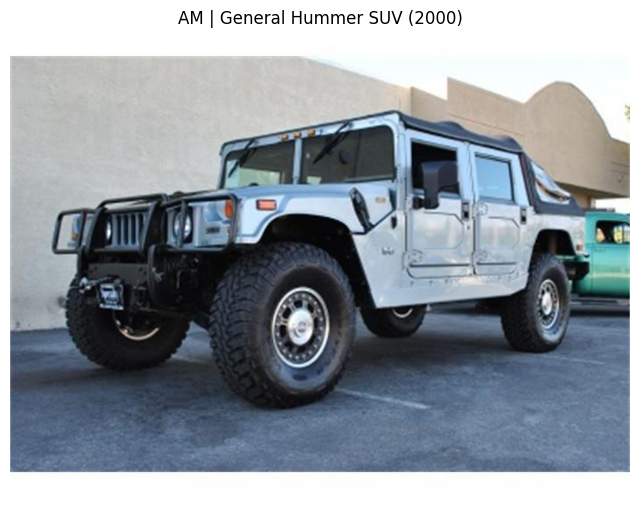

In [3]:
# Display Sample from Training Dataset

sample = dataset["train"][0]

print("-" * 60)
print("Sample Information")
print("-" * 60)

print(f"Maker : {sample['maker']}")
print(f"Model : {sample['model']}")
print(f"Year  : {sample['year']}")

print("-" * 60)


plt.figure(figsize=(8, 8))
plt.imshow(sample["image"])
plt.title(f"{sample['maker']} | {sample['model']} ({sample['year']})")
plt.axis("off")
plt.show()

# Dataset Statistics

In [4]:
# ============================================================
# Dataset Statistics & Labels
# ============================================================

train_dataset = dataset["train"]
test_dataset = dataset["test"]

train_size = len(train_dataset)
test_size = len(test_dataset)

makers = sorted(set(train_dataset["maker"]))
models = sorted(set(train_dataset["model"]))
years = sorted(set(train_dataset["year"]))

label_names = train_dataset.features["label"].names
num_classes = len(label_names)

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training Samples : {train_size:,}")
print(f"Testing Samples  : {test_size:,}")
print(f"Classes          : {num_classes}")
print(f"Manufacturers    : {len(makers)}")
print(f"Vehicle Models   : {len(models)}")
print(f"Production Years : {len(years)}")

print("-" * 60)
print("Years")
print(years)

print("-" * 60)
print("Manufacturers")
print(makers)

print("-" * 60)
print("First 5 Labels")

for i, name in enumerate(label_names[:5]):
    print(f"{i:3d} -> {name}")

print("=" * 60)

Dataset Statistics
Training Samples : 6,864
Testing Samples  : 6,751
Classes          : 196
Manufacturers    : 49
Vehicle Models   : 189
Production Years : 16
------------------------------------------------------------
Years
['1991', '1993', '1994', '1997', '1998', '1999', '2000', '2001', '2002', '2006', '2007', '2008', '2009', '2010', '2011', '2012']
------------------------------------------------------------
Manufacturers
['AM', 'Acura', 'Aston', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'Eagle', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Lamborghini', 'Land', 'Lincoln', 'MINI', 'Maybach', 'Mazda', 'McLaren', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Plymouth', 'Porsche', 'Ram', 'Rolls-Royce', 'Scion', 'Spyker', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart']
------------------------------------------------------------
First 5 Labels

# Load Model

In [5]:
# ============================================================
# Model Configuration
# ============================================================

MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"

DTYPE = torch.float16
DEVICE_MAP = "auto"

print("=" * 60)
print("Model Configuration")
print("=" * 60)
print(f"Model Name      : {MODEL_NAME}")
print(f"Torch DType     : {DTYPE}")
print(f"Device Map      : {DEVICE_MAP}")
print("=" * 60)


# ============================================================
# Load Processor
# ============================================================

processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)
processor.image_processor.size = {
    "shortest_edge": 448,
    "longest_edge": 448,
}

# ============================================================
# Load Model
# ============================================================

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
    trust_remote_code=True,
)

print("=" * 60)
print("Model Loaded Successfully")
print("=" * 60)
print(f"Model Type      : {model.config.model_type}")
print(f"Vocabulary Size : {processor.tokenizer.vocab_size:,}")
print("=" * 60)


# ============================================================
# GPU Information
# ============================================================

print("=" * 60)
print("GPU Information")
print("=" * 60)

print(f"CUDA Available  : {torch.cuda.is_available()}")
print(f"CUDA Version    : {torch.version.cuda}")
print(f"GPU Count       : {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}          : {torch.cuda.get_device_name(i)}")

print("-" * 60)
print(f"Model Device    : {next(model.parameters()).device}")
print(f"BF16 Supported  : {torch.cuda.is_bf16_supported()}")
print("=" * 60)


# ============================================================
# Training Prompts
# ============================================================

PROMPTS = [

    "Identify the manufacturer, model, and production year of this vehicle.",

    "Recognize this car and return only its manufacturer, model, and year.",

    "Analyze the image and identify the vehicle's manufacturer, model, and year.",

    "What is the manufacturer, model, and production year of the vehicle shown?",

    "Identify this vehicle as accurately as possible using manufacturer, model, and year.",

]

print("=" * 60)
print("Training Prompts")
print("=" * 60)

for i, prompt in enumerate(PROMPTS, start=1):
    print(f"{i}. {prompt}")

print("=" * 60)

Model Configuration
Model Name      : Qwen/Qwen3-VL-8B-Instruct
Torch DType     : torch.float16
Device Map      : auto


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Model Loaded Successfully
Model Type      : qwen3_vl
Vocabulary Size : 151,643
GPU Information
CUDA Available  : True
CUDA Version    : 12.8
GPU Count       : 2
GPU 0          : Tesla T4
GPU 1          : Tesla T4
------------------------------------------------------------
Model Device    : cuda:0
BF16 Supported  : True
Training Prompts
1. Identify the manufacturer, model, and production year of this vehicle.
2. Recognize this car and return only its manufacturer, model, and year.
3. Analyze the image and identify the vehicle's manufacturer, model, and year.
4. What is the manufacturer, model, and production year of the vehicle shown?
5. Identify this vehicle as accurately as possible using manufacturer, model, and year.


In [6]:
import peft
import torch
import transformers

print("Torch:", torch.__version__)
print("PEFT:", peft.__version__)
print("Transformers:", transformers.__version__)
print("PEFT path:", peft.__file__)

Torch: 2.10.0+cu128
PEFT: 0.18.0
Transformers: 4.57.1
PEFT path: /usr/local/lib/python3.12/dist-packages/peft/__init__.py


# LoRA Config

In [7]:
# ============================================================
# LoRA Configuration
# ============================================================

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

print("=" * 60)
print("LoRA Configuration")
print("=" * 60)

print(f"Rank (r)         : {lora_config.r}")
print(f"LoRA Alpha       : {lora_config.lora_alpha}")
print(f"LoRA Dropout     : {lora_config.lora_dropout}")
print(f"Target Modules   : {len(lora_config.target_modules)}")

for module in lora_config.target_modules:
    print(f"  • {module}")

print("=" * 60)


# ============================================================
# Apply LoRA
# ============================================================

model = get_peft_model(model, lora_config)

print("=" * 60)
print("LoRA Applied Successfully")
print("=" * 60)

model.print_trainable_parameters()

print("=" * 60)

LoRA Configuration
Rank (r)         : 32
LoRA Alpha       : 64
LoRA Dropout     : 0.05
Target Modules   : 7
  • down_proj
  • v_proj
  • k_proj
  • q_proj
  • up_proj
  • gate_proj
  • o_proj
LoRA Applied Successfully
trainable params: 87,293,952 || all params: 8,854,417,648 || trainable%: 0.9859


# SFTConfig

In [8]:
# ============================================================
# Training Configuration
# ============================================================

from transformers import TrainingArguments

OUTPUT_DIR = "./qwen3vl-car-lora"

training_args = TrainingArguments(

    output_dir=OUTPUT_DIR,

    num_train_epochs=1,

    # أقللها علشان الـ OOM
    per_device_train_batch_size=1,

    gradient_accumulation_steps=32,

    learning_rate=2e-4,

    fp16=True,

    dataloader_num_workers=4,
    dataloader_pin_memory=True,

    logging_steps=10,

    save_strategy="epoch",

    remove_unused_columns=False,

    report_to="none",
)

model.config.use_cache = False
model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)
model.enable_input_require_grads()

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Epochs             : {training_args.num_train_epochs}")
print(f"Batch Size         : {training_args.per_device_train_batch_size}")
print(f"Gradient Accum     : {training_args.gradient_accumulation_steps}")
print(f"Effective Batch    : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning Rate      : {training_args.learning_rate}")
print(f"Output Directory   : {training_args.output_dir}")
print("=" * 60)

Training Configuration
Epochs             : 1
Batch Size         : 1
Gradient Accum     : 32
Effective Batch    : 32
Learning Rate      : 0.0002
Output Directory   : ./qwen3vl-car-lora


In [9]:
# ============================================================
# Data Collator
# ============================================================

def collate_fn(examples):

    texts = []
    images = []

    for example in examples:

        prompt = random.choice(PROMPTS)

        answer = (
            f"Manufacturer: {example['maker']}\n"
            f"Model: {example['model']}\n"
            f"Year: {example['year']}"
        )

        conversation = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": example["image"],
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": answer,
                    }
                ],
            },
        ]

        text = processor.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        image_inputs, video_inputs = process_vision_info(conversation)

        texts.append(text)
        images.append(image_inputs)

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()

    labels[labels == processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels

    return batch


print("=" * 60)
print("Custom Data Collator Ready")
print("=" * 60)

Custom Data Collator Ready


# Trainer

In [10]:
# ============================================================
# Initialize Trainer
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collate_fn,
)

print("=" * 60)
print("Trainer Initialized Successfully")
print("=" * 60)
print(f"Training Samples : {len(dataset['train']):,}")
print(f"Training Epochs  : {training_args.num_train_epochs}")
print(f"Output Directory : {training_args.output_dir}")
print("=" * 60)

# ============================================================
# GPU Status
# ============================================================

print("CUDA Available :", torch.cuda.is_available())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("Model Device   :", next(model.parameters()).device)
print("=" * 60)

Trainer Initialized Successfully
Training Samples : 6,864
Training Epochs  : 1
Output Directory : ./qwen3vl-car-lora
CUDA Available : True
GPU 0: Tesla T4
GPU 1: Tesla T4
Model Device   : cuda:0


In [11]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

# Start Fine-Tuning

In [12]:
# ============================================================
# Start Fine-Tuning
# ============================================================

train_result = trainer.train()

print("=" * 60)
print("Training Finished")
print("=" * 60)
print(train_result)
print(trainer.state)

Step,Training Loss
10,1.851000
20,0.774900
30,0.713600
40,0.690400
50,0.681000
60,0.677300
70,0.674900
80,0.673400
90,0.668600
100,0.666200


Training Finished
TrainOutput(global_step=215, training_loss=0.7283809872560723, metrics={'train_runtime': 5915.3014, 'train_samples_per_second': 1.16, 'train_steps_per_second': 0.036, 'total_flos': 1.5820658134693632e+16, 'train_loss': 0.7283809872560723, 'epoch': 1.0})
TrainerState(epoch=1.0, global_step=215, max_steps=215, logging_steps=10, eval_steps=500, save_steps=500, train_batch_size=1, num_train_epochs=1, num_input_tokens_seen=0, total_flos=1.5820658134693632e+16, log_history=[{'loss': 1.851, 'grad_norm': 0.8456893563270569, 'learning_rate': 0.0001916279069767442, 'epoch': 0.046620046620046623, 'step': 10}, {'loss': 0.7749, 'grad_norm': 0.3401275873184204, 'learning_rate': 0.00018232558139534886, 'epoch': 0.09324009324009325, 'step': 20}, {'loss': 0.7136, 'grad_norm': 0.26734644174575806, 'learning_rate': 0.00017302325581395348, 'epoch': 0.13986013986013987, 'step': 30}, {'loss': 0.6904, 'grad_norm': 0.20832866430282593, 'learning_rate': 0.00016372093023255815, 'epoch': 0.1864

# Save LoRA Adapter

In [33]:
print(type(model))

model.print_trainable_parameters()

<class 'peft.peft_model.PeftModelForCausalLM'>
trainable params: 0 || all params: 8,767,123,696 || trainable%: 0.0000


In [36]:
# ==========================================
# Save LoRA Adapter
# ==========================================

OUTPUT_DIR = "/kaggle/working/qwen3vl-car-lora"

trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
processor.tokenizer.save_pretrained(OUTPUT_DIR)

print("LoRA saved successfully!")

LoRA saved successfully!


In [37]:
# ============================================================
# Select Test Samples
# ============================================================

NUM_SAMPLES = 5

test_samples = random.sample(
    range(len(dataset["test"])),
    NUM_SAMPLES,
)

print("=" * 60)
print(f"Testing on {NUM_SAMPLES} Random Images")
print("=" * 60)

Testing on 5 Random Images


In [38]:
import re

def parse_vehicle(text):
    manufacturer = ""
    model = ""
    year = ""

    for line in text.splitlines():
        line = line.strip()

        if line.lower().startswith("manufacturer"):
            manufacturer = line.split(":", 1)[1].strip().lower()

        elif line.lower().startswith("model"):
            model = line.split(":", 1)[1].strip().lower()

        elif line.lower().startswith("year"):
            m = re.search(r"\d{4}", line)
            if m:
                year = m.group(0)

    return manufacturer, model, year

In [39]:
# ============================================================
# Text Normalization
# ============================================================

import re

def normalize_text(text):
    """
    Normalize text before comparison.
    """

    text = text.lower().strip()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text

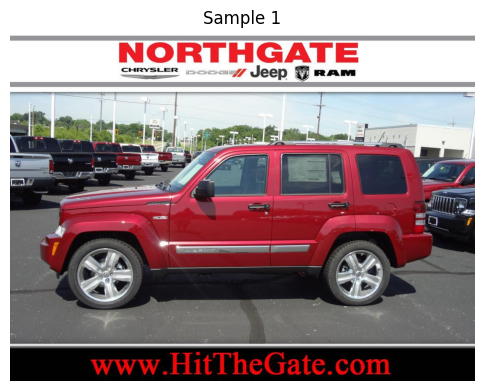

Ground Truth
Manufacturer: Jeep
Model: Liberty SUV
Year: 2012
------------------------------------------------------------
Prediction
Manufacturer: Chevrolet
Model: Malibu Sedan
Year: 2007
------------------------------------------------------------
Manufacturer : FAIL
Model        : FAIL
Year         : FAIL
------------------------------------------------------------
Overall      : FAIL


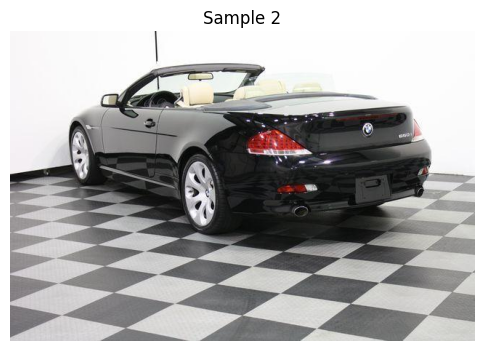

Ground Truth
Manufacturer: BMW
Model: 6 Series Convertible
Year: 2007
------------------------------------------------------------
Prediction
Manufacturer: Chevrolet
Model: Silverado 1500 Classic Extended Cab
Year: 2007
------------------------------------------------------------
Manufacturer : FAIL
Model        : FAIL
Year         : PASS
------------------------------------------------------------
Overall      : FAIL


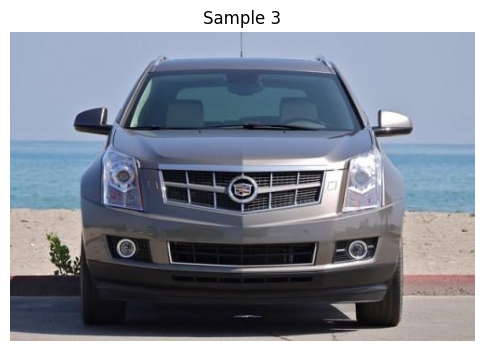

Ground Truth
Manufacturer: Cadillac
Model: SRX SUV
Year: 2012
------------------------------------------------------------
Prediction
Manufacturer: Chevrolet
Model: Silverado 1500 Classic Extended Cab
Year: 2007
------------------------------------------------------------
Manufacturer : FAIL
Model        : FAIL
Year         : FAIL
------------------------------------------------------------
Overall      : FAIL


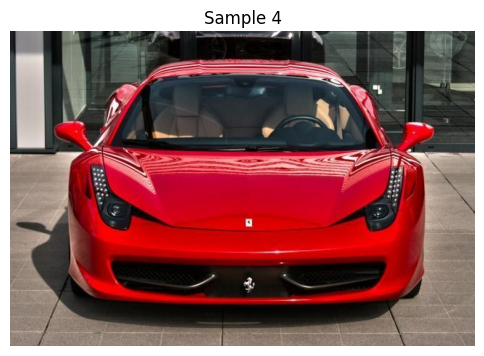

Ground Truth
Manufacturer: Ferrari
Model: 458 Italia Coupe
Year: 2012
------------------------------------------------------------
Prediction
Manufacturer: Dodge
Model: Charger SRT-8
Year: 2009
------------------------------------------------------------
Manufacturer : FAIL
Model        : FAIL
Year         : FAIL
------------------------------------------------------------
Overall      : FAIL


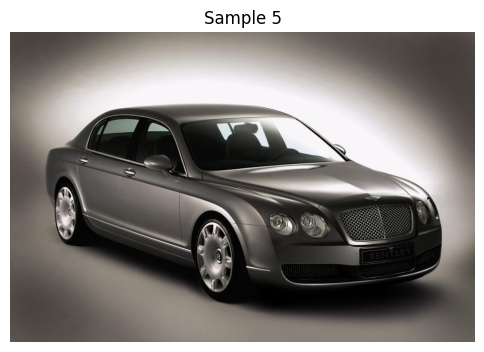

Ground Truth
Manufacturer: Bentley
Model: Continental GT Coupe
Year: 2007
------------------------------------------------------------
Prediction
Manufacturer: Chevrolet
Model: Silverado 1500 Classic Extended Cab
Year: 2007
------------------------------------------------------------
Manufacturer : FAIL
Model        : FAIL
Year         : PASS
------------------------------------------------------------
Overall      : FAIL

================ Final Results ================

Manufacturer Accuracy : 0.00%
Model Accuracy        : 0.00%
Year Accuracy         : 40.00%
Overall Accuracy      : 0.00%


In [40]:
# ============================================================
# Test Fine-Tuned Model
# ============================================================

model.eval()

try:
    model.gradient_checkpointing_disable()
except:
    pass

model.config.use_cache = True

correct = 0
manufacturer_score = 0
model_score = 0
year_score = 0
overall_score = 0

for i, idx in enumerate(test_samples, start=1):

    sample = dataset["test"][idx]

    image = sample["image"]

    ground_truth = (
        f"Manufacturer: {sample['maker']}\n"
        f"Model: {sample['model']}\n"
        f"Year: {sample['year']}"
    )

    conversation = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": random.choice(PROMPTS),
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(conversation)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            use_cache=True,
        )

    generated_ids = generated_ids[:, inputs["input_ids"].shape[1]:]

    prediction = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    prediction_clean = normalize_text(prediction)
    ground_truth_clean = normalize_text(ground_truth)

    gt_manufacturer, gt_model, gt_year = parse_vehicle(ground_truth)
    pred_manufacturer, pred_model, pred_year = parse_vehicle(prediction)

    manufacturer_correct = pred_manufacturer == gt_manufacturer
    model_correct = pred_model == gt_model
    year_correct = pred_year == gt_year

    sample_correct = (
        manufacturer_correct
        and model_correct
        and year_correct
    )

    manufacturer_score += manufacturer_correct
    model_score += model_correct
    year_score += year_correct
    overall_score += sample_correct

    is_correct = prediction_clean == ground_truth_clean

    if is_correct:
        correct += 1

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample {i}")
    plt.show()

    print("=" * 60)
    print("Ground Truth")
    print(ground_truth)
    print("-" * 60)
    print("Prediction")
    print(prediction)
    print("-" * 60)
    print(f"Manufacturer : {'PASS' if manufacturer_correct else 'FAIL'}")
    print(f"Model        : {'PASS' if model_correct else 'FAIL'}")
    print(f"Year         : {'PASS' if year_correct else 'FAIL'}")
    print("-" * 60)
    print(f"Overall      : {'PASS' if sample_correct else 'FAIL'}")
    print("=" * 60)

print("\n================ Final Results ================\n")

n = len(test_samples)

print(f"Manufacturer Accuracy : {manufacturer_score / n:.2%}")
print(f"Model Accuracy        : {model_score / n:.2%}")
print(f"Year Accuracy         : {year_score / n:.2%}")
print(f"Overall Accuracy      : {overall_score / n:.2%}")

In [32]:
# ============================================================
# Inference Summary
# ============================================================

accuracy = correct / NUM_SAMPLES * 100

print("=" * 60)
print("Inference Summary")
print("=" * 60)
print(f"Correct Predictions : {correct}/{NUM_SAMPLES}")
print(f"Accuracy            : {accuracy:.2f}%")
print("=" * 60)

Inference Summary
Correct Predictions : 0/5
Accuracy            : 0.00%
